# **Introducción a las redes convolucionales**

En este cuaderno vamos a introducir el uso de **Keras** junto con redes neuronales que contengan diversos tipos de capas (entre ellos, capas convolucionales).

En particular, resolveremos un problema de clasificación de dígitos manuscritos codificados en imágenes de profundidad 1 (blanco y negro).

# **Carga del dataset**

Obtendremos el dataset desde **Keras**. Consta de un conjunto de imágenes codificadas de tamaño 28x28, etiquetadas con el dígito de 0 a 9 al que se corresponde cada imagen.

La API de Keras devuelve los conjuntos de training (60000 patrones) y test (10000 patrones)

In [1]:
import tensorflow as tf
import numpy as np

train, test= tf.keras.datasets.mnist.load_data()
Xtrain, Ytrain= train
Xtest, Ytest= test

print('Shape de training de entrada: {} y salida: {}'.format(Xtrain.shape, Ytrain.shape))
print('Shape de test de entrada: {} y salida: {}'.format(Xtest.shape, Ytest.shape))
print('Tipo de dato usado: {}'.format(type(Xtrain)))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shape de training de entrada: (60000, 28, 28) y salida: (60000,)
Shape de test de entrada: (10000, 28, 28) y salida: (10000,)
Tipo de dato usado: <class 'numpy.ndarray'>


Vamos a mostrar algunas imágenes en MatplotLib

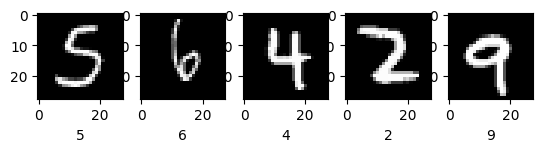

In [2]:
import matplotlib.pyplot as plt


# Mostramos algunas en matplotlib
imgs_mostrar= 5
selected= np.random.choice(range(len(Xtrain)), size=imgs_mostrar)
imgs, digits= Xtrain[ selected ], Ytrain[selected]

for i, (img, digit) in enumerate(zip(imgs, digits)):
  plt.subplot(1, 5, i+1)
  plt.imshow(img.squeeze(), cmap= 'gray')
  plt.xlabel(digit)



En TensorFlow, el procesamiento de imágenes necesita especificar de forma explítica la profundidad o **canales** que tiene cada imagen. Aunque estén en blanco y negro, es necesario y obligado explicitar que hay un único canal.

Haremos esto incluyendo una última dimensión a los datos de entrada.

In [3]:
Xtrain= np.expand_dims(Xtrain, axis= -1)
Xtest= np.expand_dims(Xtest, axis= -1)

print('Tam. de entradas para training: {} y test: {}'.format(Xtrain.shape, Xtest.shape))

Tam. de entradas para training: (60000, 28, 28, 1) y test: (10000, 28, 28, 1)


También forzaremos a que los datos estén en el intervalo [0, 1] desde su rango inicial. Como son imágenes de 8 bits, el valor de un pixel se encuentra en [0,255] (valor entero).

In [4]:
print('Rango inicial de los datos: [{}, {}]'.format(np.min(Xtrain), np.max(Xtrain)))

Xtrain= Xtrain/255
Xtest= Xtest/255

print('Rango final de los datos: [{}, {}]'.format(np.min(Xtrain), np.max(Xtrain)))


Rango inicial de los datos: [0, 255]
Rango final de los datos: [0.0, 1.0]


Pasemos ahora los datos a tensor:

In [5]:
tXtrain, tYtrain= tf.convert_to_tensor(Xtrain), tf.convert_to_tensor(Ytrain, dtype=tf.int32)
tXtest, tYtest= tf.convert_to_tensor(Xtest), tf.convert_to_tensor(Ytest, dtype=tf.int32)

# **Construcción del modelo**

[LeNet5](https://en.wikipedia.org/wiki/LeNet) fue una de las primeras redes convolucionales, y se empleó exitosamente ya en los años 90 en la clasificación de dígitos manuscritos. Véase, por ejemplo, _LeCun et al. (1998). Gradient based learning applied to document recognition. Proceedings of the IEEE. 86(11): 2278-2324_.

En este cuaderno emplearemos una versión ligeramente modificada de la misma, que consta de las siguientes capas (**FC= Fully Connected**, capa densa):


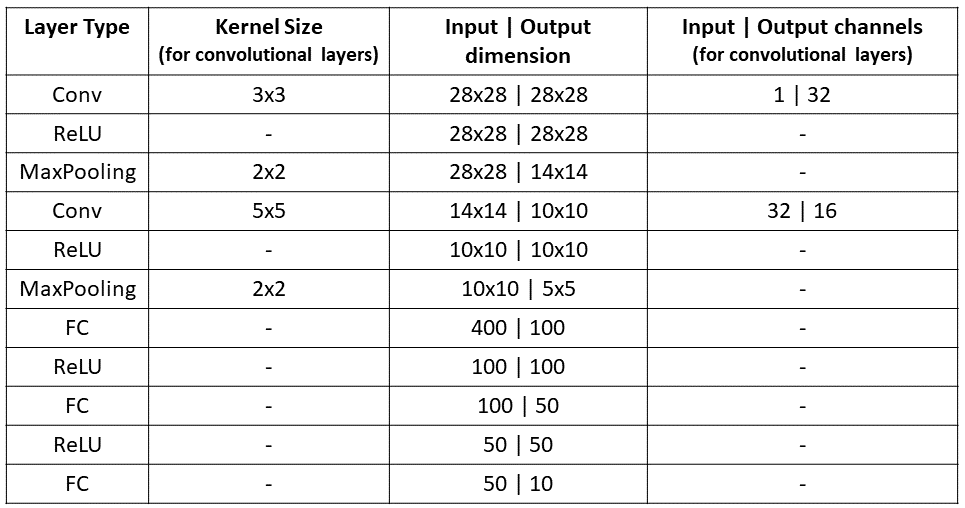

In [6]:
from tensorflow.keras import Input, Sequential
from tensorflow.keras.layers import Conv2D, Dense, MaxPooling2D, Flatten

model= Sequential()
model.add( Input(shape= (tXtrain.shape[1], tXtrain.shape[2], tXtrain.shape[3])) ) # 28x28x1 (se podría haber puesto directamente)

# Primeras capas conv + relu + MaxPooling
model.add( Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')) # No sale stride ya que por defecto es 1
model.add( MaxPooling2D(pool_size=(2,2)) )

# Segundas capas conv + relu + MaxPooling
model.add( Conv2D(filters=16, kernel_size=(5,5), padding='valid', activation='relu'))
model.add( MaxPooling2D(pool_size=(2,2)) )

# Transformación para procesamiento por capa densa
model.add( Flatten() )

# Primera capa densa + relu
model.add( Dense(100, activation='relu') ) # La función de activación depende de cómo quiera entrenar

# Segunda capa densa + relu
model.add( Dense(50, activation='relu') )

# Capa densa de salida (softmax para clasificación)
model.add( Dense(10, activation='softmax') )

# La salida la voy a interpretar como la probablidad de que sea cada número
# por ejemplo salida[1] = probabilidad de que lo que haya en la imagen sea un 1

# **Selección de función de pérdida**

Usaremos **tf.keras.losses.sparse_categorical_crossentropy**, que es la entropía cruzada categórica que ya vimos en el cuaderno anterior, pero que acepta que las salidas estén dadas como números enteros en lugar de como OneHot.

In [7]:
from tensorflow.keras.losses import sparse_categorical_crossentropy

loss_function= sparse_categorical_crossentropy

# **Algoritmo de aprendizaje**

En este caso usaremos **Adam**, con una tasa de aprendizaje reducida.

In [8]:
from tensorflow.keras.optimizers import Adam


lmbda= 0.001 # Tasa de aprendizaje
optimizer= Adam(learning_rate= lmbda)

# **Métricas de validación de modelo**

Usaremos sólo el accuracy, dado que es un ejemplo de cómo funciona Keras con capas convolucionales.

In [9]:
metrics= ['accuracy']

# **Compilación del modelo**

In [10]:
model.compile(optimizer=optimizer, loss=loss_function, metrics=metrics)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │        12,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,796 (229.67 KB)

 Trainable params: 58,796 (229.67 KB)

 Non-trainable params: 0 (0.00 B)

# **Entrenamiento**

Para acelerar el cálculo, usaremos GPUs. **Editar -> Configuración del cuaderno -> GPU T4**.

Hará falta reiniciar el entorno de ejecución y lanzar todo de nuevo.

In [11]:
epochs= 50 # 50 épocas de prueba
bs= 10000 # En batches de 10000 para reducir el tiempo (normalmente potencia de 2 para optimizar los recursos de la GPU)

model.fit(tXtrain, tYtrain, batch_size=bs, epochs=epochs)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.1746 - loss: 2.2458
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.4987 - loss: 1.9229
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.6768 - loss: 1.3039
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.8121 - loss: 0.7143
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.8619 - loss: 0.4527
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.8879 - loss: 0.3647
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.9067 - loss: 0.3086
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.9187 - loss: 0.2721
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.9275 - loss: 0.2399
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.9344 - loss: 0.2159
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.9415 - loss: 0.1952
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.9465 - l

# **Validación**

Probemos ahora cómo funciona el modelo en train y test.

In [12]:
ScoresTrain= model.evaluate(tXtrain, tYtrain)
ScoresTest= model.evaluate(tXtest, tYtest)
print('CONJUNTO DE ENTRENAMIENTO')
print('\tLoss Value: {}'.format(ScoresTrain[0]))
for i in range(len(metrics)):
  print('\t{}: {}'.format(metrics[i], ScoresTrain[i+1]))

print('\nCONJUNTO DE TEST')
print('\tLoss Value: {}'.format(ScoresTest[0]))
for i in range(len(metrics)):
  print('\t{}: {}'.format(metrics[i], ScoresTest[i+1]))


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9876 - loss: 0.0406
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9860 - loss: 0.0428
CONJUNTO DE ENTRENAMIENTO
	Loss Value: 0.04064951092004776
	accuracy: 0.9876166582107544

CONJUNTO DE TEST
	Loss Value: 0.04282378405332565
	accuracy: 0.9860000014305115
